In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [5]:
df= pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


<Axes: xlabel='age', ylabel='Count'>

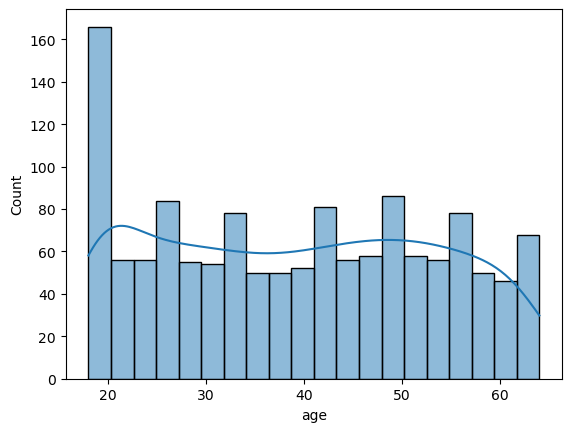

In [8]:
sns.histplot(data=df,x="age",kde=True,bins=20)

<Axes: xlabel='bmi', ylabel='Count'>

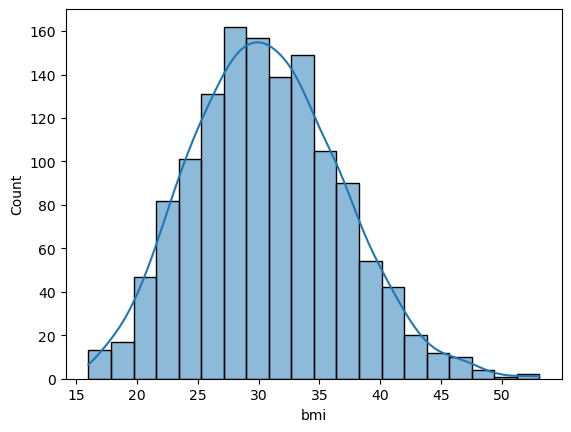

In [9]:
sns.histplot(data=df,x="bmi",kde=True,bins=20)

<Axes: xlabel='children', ylabel='Count'>

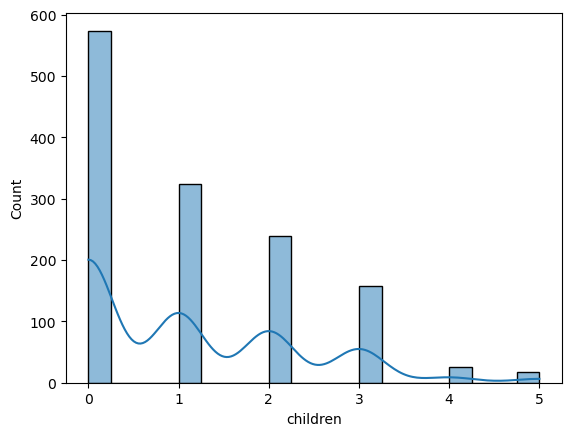

In [10]:
sns.histplot(data=df,x="children",kde=True,bins=20)

<Axes: xlabel='children', ylabel='expenses'>

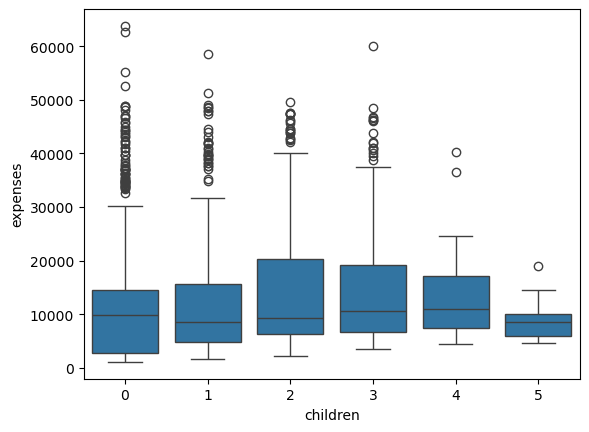

In [12]:

sns.boxplot(data=df, x="children",y="expenses")

<Axes: xlabel='expenses', ylabel='smoker'>

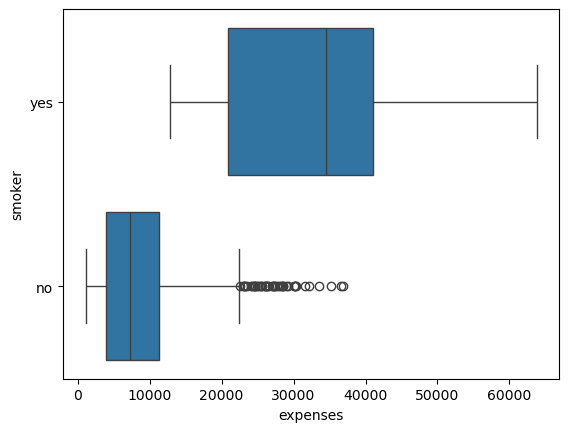

In [15]:

sns.boxplot(data=df, x="expenses",y="smoker")

<Axes: xlabel='expenses', ylabel='region'>

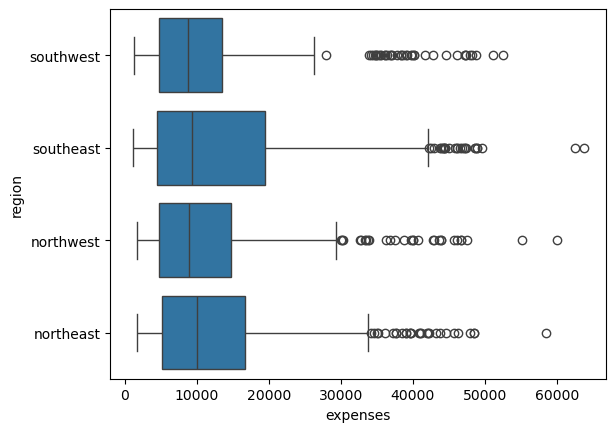

In [16]:
sns.boxplot(data=df, x="expenses",y="region")

<Axes: xlabel='sex', ylabel='count'>

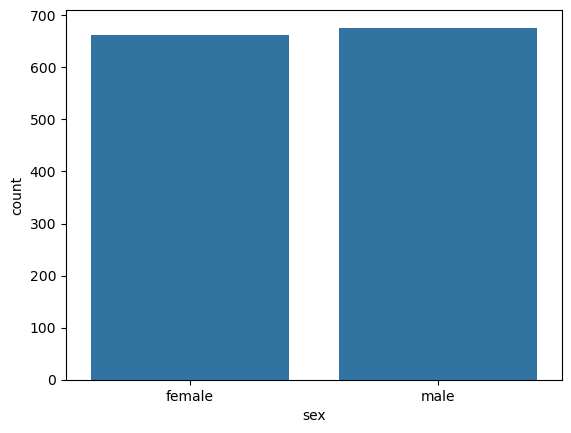

In [17]:
sns.countplot(data = df, x="sex")

In [18]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(1)

In [21]:
df= df.drop_duplicates()

<Axes: >

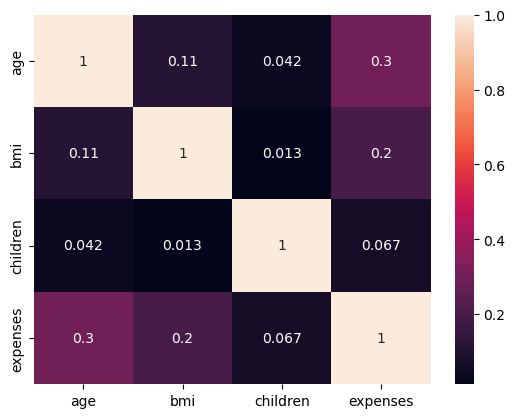

In [23]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [25]:
# select the cols for training
x=df[["age"]]
y= df[["expenses"]]

In [26]:
# data split into train and tests:
from sklearn.model.model_selection import train_test_split

ModuleNotFoundError: No module named 'sklearn.model'

In [31]:
pip install sklearn

Defaulting to user installation because normal site-packages is not writeable
  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [15 lines of output]
  The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
  rather than 'sklearn' for pip commands.
  
  Here is how to fix this error in the main use cases:
  - use 'pip install scikit-learn' rather than 'pip install sklearn'
  - replace 'sklearn' by 'scikit-learn' in your pip requirements files
    (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
  - if the 'sklearn' package is used by one of your dependencies,
    it would be great if you take some time to track which package uses
    'sklearn' instead of 'scikit-learn' and report it to their issue tracker
  - as a last resort, set the environment variable
    SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
  
  More information is available at
  https://github.com/scikit-learn/sklearn-pypi-package
  [end of output]
  
  note: This error originates f

In [39]:
# data split into train and tests:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
x_train, x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=25)

In [41]:

model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
model.coef_

array([[242.56517177]])

In [44]:
model.intercept_

array([3769.43696469])

In [45]:
y_pred = model.predict(x_test)

In [46]:
y_pred

array([[15170.00003801],
       [16140.26072511],
       [15412.56520979],
       [14442.30452269],
       [16140.26072511],
       [ 8135.6100566 ],
       [13957.17417915],
       [14684.86969447],
       [17838.21692752],
       [12259.21797674],
       [11531.52246142],
       [14442.30452269],
       [ 8378.17522837],
       [13957.17417915],
       [12016.65280497],
       [12986.91349206],
       [ 9348.43591546],
       [16625.39106865],
       [ 8863.30557192],
       [10318.69660255],
       [15412.56520979],
       [10561.26177433],
       [12016.65280497],
       [17838.21692752],
       [17110.5214122 ],
       [14927.43486624],
       [15412.56520979],
       [14199.73935092],
       [ 8620.74040014],
       [19293.60795815],
       [15170.00003801],
       [ 8378.17522837],
       [11046.39211787],
       [13714.60900738],
       [17595.65175574],
       [17353.08658397],
       [17838.21692752],
       [10076.13143078],
       [15170.00003801],
       [17595.65175574],


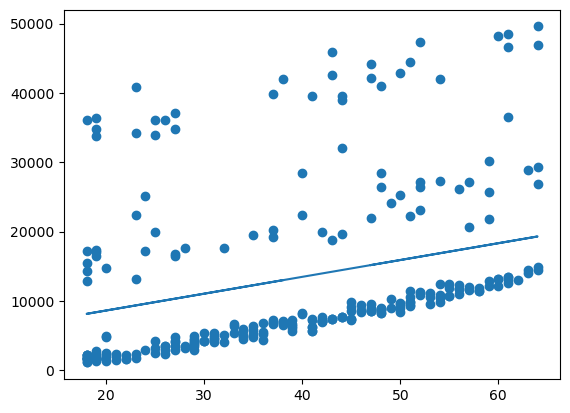

In [47]:
plt.plot(x_test,y_pred)
plt.scatter(x_test,y_test)

In [50]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

9116.657516733074
128861058.65267788
0.12593246349669673


In [52]:
x= df.drop("expenses",axis=1)
x = pd.get_dummies(x, drop_first=True)


In [53]:
x

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,False,True,False,False,True
1,18,33.8,1,True,False,False,True,False
2,28,33.0,3,True,False,False,True,False
3,33,22.7,0,True,False,True,False,False
4,32,28.9,0,True,False,True,False,False
...,...,...,...,...,...,...,...,...
1333,50,31.0,3,True,False,True,False,False
1334,18,31.9,0,False,False,False,False,False
1335,18,36.9,0,False,False,False,True,False
1336,21,25.8,0,False,False,False,False,True


In [55]:
y = df['expenses']

In [56]:
y

0       16884.92
1        1725.55
2        4449.46
3       21984.47
4        3866.86
          ...   
1333    10600.55
1334     2205.98
1335     1629.83
1336     2007.95
1337    29141.36
Name: expenses, Length: 1337, dtype: float64

In [59]:
x_train, x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=25)
model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
print(model.coef_)
print(model.intercept_)

4280.661978961793
35313092.98810559
0.7604704748110177
[  254.00951096   342.52998957   442.96920297   -40.70918629
 23971.99068056    31.25331142 -1246.37069538  -880.78390129]
-12010.42350432416


In [66]:
# age= 2 , bmi = 28 ,sex = "male",smoker = yes
# region= northeast
# children = 2
x_train, x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=25)
model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
print(model.coef_)
print(model.intercept_)
model.predict(np.array([[20,28,2,0,1,0,1,1]]))
x

4280.661978961793
35313092.98810559
0.7604704748110177
[  254.00951096   342.52998957   442.96920297   -40.70918629
 23971.99068056    31.25331142 -1246.37069538  -880.78390129]
-12010.42350432416


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,False,True,False,False,True
1,18,33.8,1,True,False,False,True,False
2,28,33.0,3,True,False,False,True,False
3,33,22.7,0,True,False,True,False,False
4,32,28.9,0,True,False,True,False,False
...,...,...,...,...,...,...,...,...
1333,50,31.0,3,True,False,True,False,False
1334,18,31.9,0,False,False,False,False,False
1335,18,36.9,0,False,False,False,True,False
1336,21,25.8,0,False,False,False,False,True


In [67]:
df= pd.read_csv("Fish.csv")
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [68]:
df.isna().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [69]:
df.duplicated().sum()

np.int64(0)

118.12023386278423
20672.038726757335
0.7714604379571602
[ 55.73253942  -3.71705088 -25.43124997  25.21485685  26.45511966]
-509.26944600754416
101.86588356334946
16141.151116598645
0.8979646365192799
[ 57.52068116  -5.34669064 -26.00002808  24.93388258  27.42246449]
-496.7489443247519
93.25209148137223
13690.667409856042
0.8980209372627835
[ 58.39108257  -2.26541421 -29.55652244  26.62330456  24.25661486]
-497.9046057327895
103.90941708422304
16763.887193140767
0.8821430593048694
[ 43.5352649    7.82179624 -25.25670105  23.2289123   27.06649294]
-515.305651338433
95.36828906864321
15271.289203414166
0.8828776020785213
[ 51.43500443   6.44757662 -29.95777296  25.8537637   17.27336678]
-513.6495118585165
[346.84913618]


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


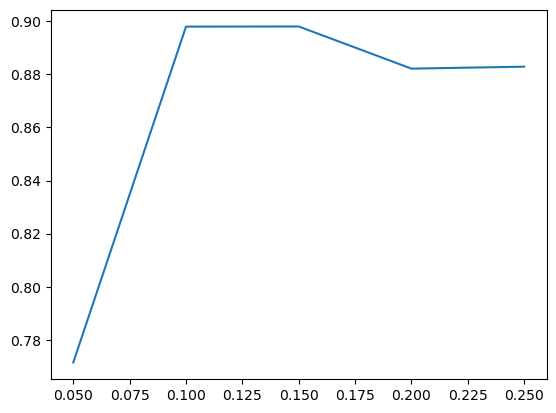

In [76]:
# test size - 0.05 ,0.1, 0.15, 0.2, 0.25
df.isna().sum()
x = df.drop(['Species','Weight'],axis=1)
y = df['Weight']
r2=[]
test=[0.05,0.1,0.15,0.2, 0.25]
for i in test:
    x_train, x_test , y_train , y_test = train_test_split(x,y,test_size=i,random_state=42)
    model = LinearRegression()
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)

    r2.append(r2_score(y_test,y_pred))
    if r2_score(y_test,y_pred):
        r2_max =  r2_score(y_test,y_pred)
        y_ans = model.predict(np.array([[20,20,20,5,10]]))
    
    
    print(mean_absolute_error(y_test,y_pred))
    print(mean_squared_error(y_test,y_pred))
    print(r2_score(y_test,y_pred))
    print(model.coef_)
    print(model.intercept_)
    
print(y_ans)
plt.plot(test,r2)